In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from matplotlib.image import imread
from PIL import Image
import cv2
import shutil
import numpy as np
from tqdm import tqdm
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization,GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adamax, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.models import load_model

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

import warnings
warnings.filterwarnings('ignore')

In [4]:
landmarks_path= Path("/kaggle/input/final-landmark-dataset/Final Dataset 4 JPG")
classes = os.listdir(landmarks_path)
print(classes)

['The Small Aten Temple', 'Qasr Qarun', 'Pyramid of Meidum', 'Temple of Kom Ombo', 'Temple of Luxor', 'Temple of Isis in Philae', 'Temple of Hathor in Philae', 'Pyramid of Senefru - Bent Pyramid of Senefru', 'Temple of Dakka', 'Temple of Hathor in Dendera', 'Temple of Maharraqa', 'Pyramids of Giza', 'Black Pyramid of Amenemhat III', 'Temple of Horus at Edfu', 'Famine Stele', 'Al Qurn', 'Small Temple of Hathor and Nefertari at Abu Simbel', 'Sphinx', 'Temple of Kalabsha', 'Ptolemaic Temple of Hathor in Deir el Medina', 'Kiosk of Trajan in Philae', 'Temple of Khonsu in Karnak', 'Temple of Karnak', 'Colossoi of Memnon', 'Pyramid of Seila', 'Temple of Hatshepsut in Deir El Bahari', 'Temple of Habu', 'Osireion', 'Ramessum', 'Pyramid of Saqqara - Pyramid of Djoser', 'Temple of Amada', 'Tomb of Horemheb in Saqqara', 'Pyramid of Sahure', 'Sphinx of Memphis', 'Temple of Seti I in Abydos', 'The Roman Mammisi in Dendera', 'Temple of Wadi es-Sebua - Temple of Ramesses II', 'Tomb of Petosiris', 'Tem

In [5]:
len(classes)

52

## Utility Functions

In [6]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def count_images_recursive(path: Path):
    return sum(1 for p in path.rglob("*") if p.suffix.lower() in IMG_EXTS)

def count_images_in_dir(path: Path):
    return sum(1 for p in path.iterdir() if p.suffix.lower() in IMG_EXTS)

In [7]:
def make_df(landmarks_path: Path):
    rows = []

    for class_dir in list_subdirs(landmarks_path):
        landmark_name = os.path.basename(class_dir)
        for p in class_dir.iterdir():
            if p.suffix.lower() in IMG_EXTS:
                rows.append({"label": str(landmark_name)  , "path": str(p)})

    df = pd.DataFrame(rows, columns=["label", "path"])
    return df

df=make_df(landmarks_path)
df.sample(10)

,label,path
1304,Pyramid of Saqqara - Pyramid of Djoser,/kaggle/input/final-landmark-dataset/Final Dat...
3547,Sphinx of Memphis,/kaggle/input/final-landmark-dataset/Final Dat...
1920,Pyramid of Unas,/kaggle/input/final-landmark-dataset/Final Dat...
2685,Pyramids of Giza,/kaggle/input/final-landmark-dataset/Final Dat...
4514,Temple of Horus at Edfu,/kaggle/input/final-landmark-dataset/Final Dat...
5921,Tomb of Horemheb in Saqqara,/kaggle/input/final-landmark-dataset/Final Dat...
806,Kiosk of Trajan in Philae,/kaggle/input/final-landmark-dataset/Final Dat...
910,Pompeys Pillar - Serapeum of Alexandria,/kaggle/input/final-landmark-dataset/Final Dat...
4316,Temple of Hatshepsut in Deir El Bahari,/kaggle/input/final-landmark-dataset/Final Dat...
512,Colossoi of Memnon,/kaggle/input/final-landmark-dataset/Final Dat...


In [8]:
print("Dataframe shape:", df.shape)

Dataframe shape: (6000, 2)


## Data Preprocessing

label
Pyramids of Giza                                      814
Temple of Hatshepsut in Deir El Bahari                455
Pyramid of Senefru - Bent Pyramid of Senefru          439
Colossoi of Memnon                                    436
The Great Temple of Ramesses II at Abu Simbel         363
Sphinx                                                337
Pyramid of Saqqara - Pyramid of Djoser                252
Ramessum                                              219
Temple of Horus at Edfu                               192
Kiosk of Trajan in Philae                             171
Temple of Kom Ombo                                    161
Temple of Luxor                                       146
Temple of Isis in Philae                              144
Temple of Hathor in Dendera                           114
Pompeys Pillar - Serapeum of Alexandria               111
Small Temple of Hathor and Nefertari at Abu Simbel     99
Temple of Karnak                                       94
Black Py

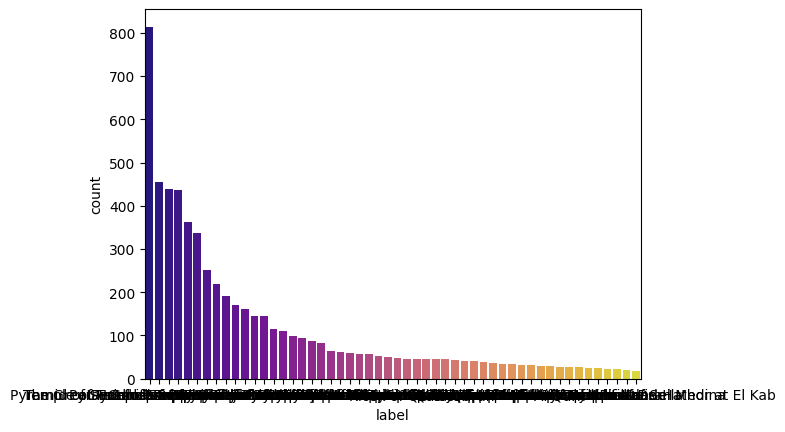

In [9]:
sns.countplot(data=df,x='label',palette='plasma',order=df['label'].value_counts().index )
df['label'].value_counts()

In [10]:
def show(title, img):
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def load_bgr(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read {path}")
    return img_bgr

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [11]:
image_size = 256
def resize(image, size=image_size):
  return cv2.resize(image,(size,size), interpolation=cv2.INTER_AREA)

In [12]:
train_aug = A.Compose([
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.2),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REPLICATE, p=0.5),  # make sure border_mode is set here too
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, border_mode=cv2.BORDER_REPLICATE, p=0.6)
])

def apply_augmentation(image):
    return train_aug(image=image)["image"]

In [13]:
def normalize(image):
  return image/255.0

In [14]:
sample_row = df.iloc[3903]
sample_path = sample_row["path"]
sample_label = sample_row["label"]

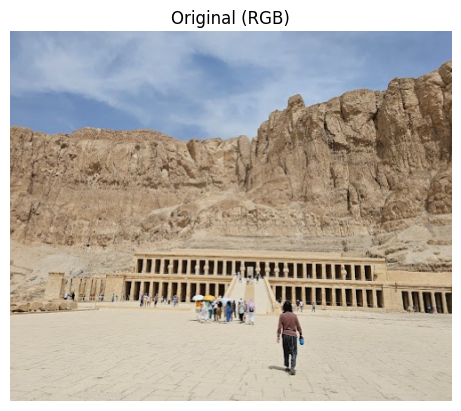

Original shape: (416, 497, 3) dtype: uint8


In [15]:
image_BGR = load_bgr(sample_path)
image_RGB = bgr_to_rgb(image_BGR)

show("Original (RGB)", image_RGB)
print("Original shape:", image_RGB.shape, "dtype:", image_RGB.dtype)

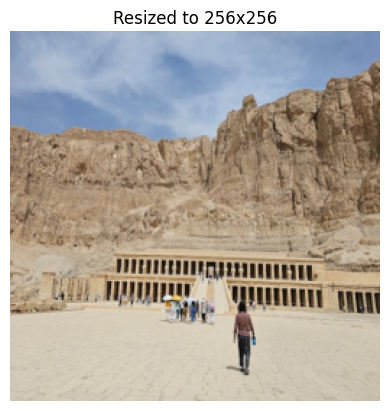

Resized shape: (256, 256, 3)


In [16]:
image_resized= resize(image_RGB,image_size)
show(f"Resized to {image_size}x{image_size}", image_resized)
print("Resized shape:", image_resized.shape)

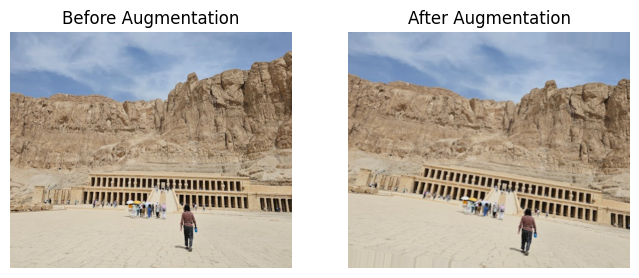

In [17]:
image_augmented = apply_augmentation(image_RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(image_RGB); plt.title("Before Augmentation"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(image_augmented); plt.title("After Augmentation");  plt.axis("off")
plt.show()

In [18]:
def preprocess_image(path, size=image_size, augment=False):
    image_BGR = load_bgr(path)
    image_RGB = bgr_to_rgb(image_BGR)
    image_resized = resize(image_RGB, size)

    if augment:
        image_processed = apply_augmentation(image_resized)
    else:
        image_processed = image_resized

    #image_normalized = normalize(image_processed)
    return image_processed


In [19]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class TFDataset:
    def __init__(self, df, augment=False, batch_size=BATCH_SIZE, shuffle=True, image_size=image_size):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_and_preprocess(self, path, label):
        def _py_preprocess(path_str):
            path_str = path_str.decode("utf-8")
            img = preprocess_image(
                path_str,
                size=self.image_size,
                augment=self.augment
            )
            return img.astype("float32")

        img = tf.numpy_function(_py_preprocess, [path], tf.float32)
        img.set_shape((self.image_size, self.image_size, 3))
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label"].values.astype("float32")

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if self.shuffle:
            ds = ds.shuffle(buffer_size=len(self.df), reshuffle_each_iteration=True)

        ds = ds.map(self._load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(self.batch_size)
        ds = ds.prefetch(AUTOTUNE)
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

## Model

### Data Split

In [20]:
df.shape[0]

6000

In [21]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.3,
    stratify=temp_df["label"],
    random_state=42
)

In [22]:
train_df['label'].value_counts()

label
Pyramids of Giza                                      651
Temple of Hatshepsut in Deir El Bahari                364
Pyramid of Senefru - Bent Pyramid of Senefru          351
Colossoi of Memnon                                    349
The Great Temple of Ramesses II at Abu Simbel         290
Sphinx                                                269
Pyramid of Saqqara - Pyramid of Djoser                202
Ramessum                                              175
Temple of Horus at Edfu                               154
Kiosk of Trajan in Philae                             137
Temple of Kom Ombo                                    129
Temple of Luxor                                       117
Temple of Isis in Philae                              115
Temple of Hathor in Dendera                            91
Pompeys Pillar - Serapeum of Alexandria                89
Small Temple of Hathor and Nefertari at Abu Simbel     79
Temple of Karnak                                       75
Black Py

In [23]:
print("Train size:", train_df.shape[0])
print("Test size:", test_df['label'].shape[0])
print("Valid size:", valid_df['label'].shape[0])


Train size: 4800
Test size: 360
Valid size: 840


In [112]:
"""import os
import cv2
from tqdm import tqdm

def get_multiplier(n):
    if n <= 50:
        return 10
    elif n <= 150:
        return 4
    elif n <= 300:
        return 2
    else:
        return 1

def generate_augmented_dataset(train_df, train_aug, output_dir="augmented_train"):
    os.makedirs(output_dir, exist_ok=True)

    for label, group in tqdm(train_df.groupby("label")):
        class_dir = os.path.join(output_dir, str(label).replace(" ", "_"))
        os.makedirs(class_dir, exist_ok=True)

        n_original = len(group)
        multiplier = get_multiplier(n_original)
        total_needed = n_original * multiplier

        counter = 0

        # save original images
        for _, row in group.iterrows():
            img = cv2.imread(row["path"])
            if img is None:
                continue

            cv2.imwrite(
                os.path.join(class_dir, f"{counter}_orig.jpg"),
                img
            )
            counter += 1

        # generate augmented images
        while counter < total_needed:
            for _, row in group.iterrows():
                img = cv2.imread(row["path"])
                if img is None:
                    continue

                aug_img = train_aug(image=img)["image"]
                cv2.imwrite(
                    os.path.join(class_dir, f"{counter}_aug.jpg"),
                    aug_img
                )
                counter += 1

                if counter >= total_needed:
                    break

        # 🔍 per-class report
        print(
            f"Class: {label} | "
            f"Original: {n_original} | "
            f"Multiplier: {multiplier} | "
            f"Target: {total_needed} | "
            f"Saved: {counter}"
        )

generate_augmented_dataset(train_df, train_aug, output_dir="augmented_train")"""

100%|██████████| 52/52 [1:01:33<00:00, 71.03s/it]


In [24]:
augmented_data = []
base_dir = Path("/kaggle/input/landmarks-augmented-dataset/augmented_train")


for class_name in os.listdir(base_dir):
    class_dir = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        path = os.path.join(class_dir, fname)
        augmented_data.append({"path": path, "label": class_name.replace("_", " ")})

aug_df = pd.DataFrame(augmented_data)
aug_df.shape

(17731, 2)

In [25]:
aug_df.sample(10)

,path,label
5832,/kaggle/input/landmarks-augmented-dataset/augm...,Pyramid of Hawara - White pyramid of Amnemhat III
9718,/kaggle/input/landmarks-augmented-dataset/augm...,The Great Temple of Ramesses II at Abu Simbel
8929,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Hatshepsut in Deir El Bahari
5558,/kaggle/input/landmarks-augmented-dataset/augm...,Famine Stele
7935,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Kalabsha
2664,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Luxor
4291,/kaggle/input/landmarks-augmented-dataset/augm...,Pyramid of Userkaf
2769,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Luxor
17039,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Esna
12678,/kaggle/input/landmarks-augmented-dataset/augm...,Speos of Horemheb


### Label Encoding

In [26]:
encoder = LabelEncoder()

aug_df['label'] = encoder.fit_transform(aug_df['label'])

test_df['label'] = encoder.transform(test_df['label'])
valid_df['label'] = encoder.transform(valid_df['label'])


In [27]:
counts = aug_df['label'].value_counts()
counts.index = encoder.inverse_transform(counts.index.astype(int))

counts

Pyramids of Giza                                      651
The Great Temple of Ramesses II at Abu Simbel         580
Kiosk of Trajan in Philae                             548
Sphinx                                                538
Temple of Kom Ombo                                    516
Temple of Dakka                                       490
Pyramid of Userkaf                                    470
Temple of Luxor                                       468
Pyramid of Hawara - White pyramid of Amnemhat III     460
Temple of Merit Amun                                  460
Temple of Isis in Philae                              460
The Roman Mammisi in Dendera                          420
Temple of Seti I in Abydos                            410
Pyramid of Saqqara - Pyramid of Djoser                404
Famine Stele                                          390
Temple of Kalabsha                                    370
Kiosk of Qertassi                                     370
Temple of Hats

### Class Weights

In [28]:
aug_df['label'].values

array([39, 39, 39, ..., 41, 41, 41])

In [29]:
y = aug_df['label']  # convert strings to int

classes = np.unique(y)
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weights = dict(zip(classes, class_weights_array))

print(class_weights)

{np.int64(0): np.float64(1.5499125874125874), np.int64(1): np.float64(1.2177884615384615), np.int64(2): np.float64(0.9770222614062155), np.int64(3): np.float64(0.8743096646942801), np.int64(4): np.float64(0.9215696465696466), np.int64(5): np.float64(0.622227681078046), np.int64(6): np.float64(1.7049038461538462), np.int64(7): np.float64(0.9578111495246326), np.int64(8): np.float64(1.5499125874125874), np.int64(9): np.float64(0.74126254180602), np.int64(10): np.float64(1.2915938228438228), np.int64(11): np.float64(1.671474358974359), np.int64(12): np.float64(0.8440118050266565), np.int64(13): np.float64(2.0057692307692307), np.int64(14): np.float64(0.9714551829936445), np.int64(15): np.float64(1.7049038461538462), np.int64(16): np.float64(0.7254909983633387), np.int64(17): np.float64(0.5237799834574028), np.int64(18): np.float64(1.0028846153846154), np.int64(19): np.float64(0.9742307692307692), np.int64(20): np.float64(1.0790530671859786), np.int64(21): np.float64(1.363923076923077), np

In [30]:
train_data = TFDataset(
    aug_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=True,
    image_size=256)

val_data = TFDataset(
    valid_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=256
)

I0000 00:00:1769023484.063105      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [31]:
print("Number of samples:", len(train_data.df))
print("Number of batches:", len(train_data))

Number of samples: 17731
Number of batches: 555


### Model Building and Training

In [36]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model=MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(256, 256, 3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(52, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 52)             │        13,364 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,058,548 (11.67 MB)

 Trainable params: 800,564 (3.05 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [37]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
history = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss',mode='min',patience=6,restore_best_weights=True)],
    class_weight=class_weights
)

Epoch 1/15


I0000 00:00:1769023705.208095     127 service.cc:152] XLA service 0x7d782c003a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769023705.208141     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769023706.619737     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769023714.613180     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


555/555 ━━━━━━━━━━━━━━━━━━━━ 90s 133ms/step - accuracy: 0.1521 - loss: 3.5057 - val_accuracy: 0.8524 - val_loss: 0.9881
Epoch 2/15
555/555 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.6023 - loss: 1.5310 - val_accuracy: 0.9381 - val_loss: 0.4027
Epoch 3/15
555/555 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.7570 - loss: 0.8866 - val_accuracy: 0.9607 - val_loss: 0.2380
Epoch 4/15
555/555 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.8326 - loss: 0.6079 - val_accuracy: 0.9702 - val_loss: 0.1671
Epoch 5/15
555/555 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.8721 - loss: 0.4607 - val_accuracy: 0.9798 - val_loss: 0.1269
Epoch 6/15
555/555 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.9030 - loss: 0.3502 - val_accuracy: 0.9810 - val_loss: 0.0940
Epoch 7/15
555/555 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.9212 - loss: 0.2875 - val_accuracy: 0.9857 - val_loss: 0.0768
Epoch 8/15
555/555 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.9372 - loss: 0.2235 - val_accura

In [39]:
base_model.trainable = True 

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [41]:
histor2y = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/30


2026-01-21 19:40:35.862356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 19:40:36.058926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


555/555 ━━━━━━━━━━━━━━━━━━━━ 138s 159ms/step - accuracy: 0.8594 - loss: 0.4837 - val_accuracy: 0.9857 - val_loss: 0.0399 - learning_rate: 1.0000e-04
Epoch 2/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 53s 96ms/step - accuracy: 0.9735 - loss: 0.0814 - val_accuracy: 0.9917 - val_loss: 0.0350 - learning_rate: 1.0000e-04
Epoch 3/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 53s 95ms/step - accuracy: 0.9821 - loss: 0.0599 - val_accuracy: 0.9940 - val_loss: 0.0185 - learning_rate: 1.0000e-04
Epoch 4/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 53s 95ms/step - accuracy: 0.9908 - loss: 0.0272 - val_accuracy: 0.9964 - val_loss: 0.0186 - learning_rate: 1.0000e-04
Epoch 5/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 53s 95ms/step - accuracy: 0.9942 - loss: 0.0200 - val_accuracy: 0.9976 - val_loss: 0.0212 - learning_rate: 1.0000e-04
Epoch 6/30
554/555 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9938 - loss: 0.0222
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
555/555 ━━━━━━━━━━━━━━━━━━━━ 53s 95ms/step - accuracy: 

### Model Evaluation

In [42]:
losses=pd.DataFrame(histor2y.history)

Text(0.5, 1.0, 'Model Accuracy during Training')

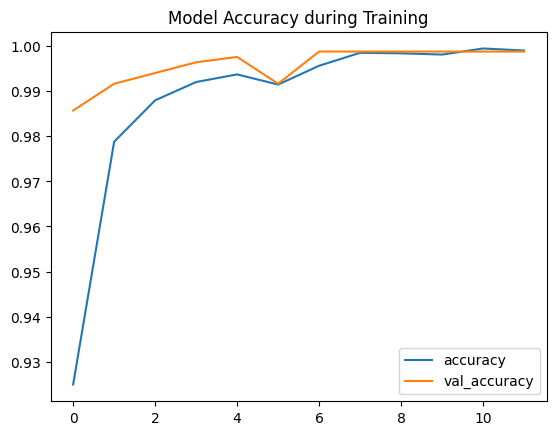

In [43]:
losses[['accuracy','val_accuracy']].plot()
plt.title('Model Accuracy during Training')

Text(0.5, 1.0, 'Model Loss during Training')

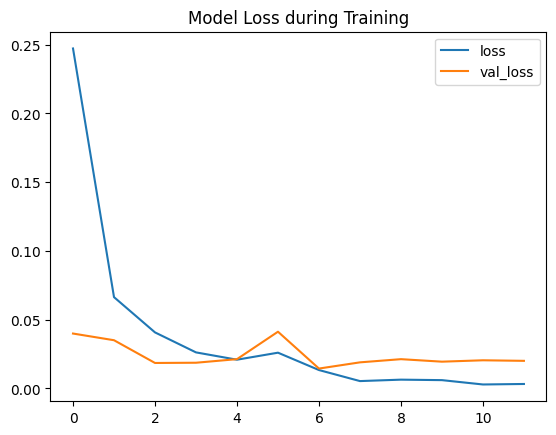

In [44]:
losses[['loss','val_loss']].plot()
plt.title('Model Loss during Training')

In [45]:
val_loss, val_accuracy=model.evaluate(val_data.dataset)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9995 - loss: 0.0074
Validation Loss: 0.0144
Validation Accuracy: 0.9988


In [46]:
test_data = TFDataset(
    test_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=image_size,
)

In [47]:
print("Number of samples:", len(test_data.df))
print("Number of batches:", len(test_data))

Number of samples: 360
Number of batches: 12


In [48]:
y_true = np.concatenate([y for x, y in val_data.dataset], axis=0)
y_pred = np.argmax(model.predict(val_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 258ms/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         4
         1.0       1.00      1.00      1.00        13
         2.0       1.00      1.00      1.00        61
         3.0       1.00      1.00      1.00         7
         4.0       1.00      1.00      1.00         6
         5.0       1.00      1.00      1.00        24
         6.0       1.00      1.00      1.00         4
         7.0       1.00      1.00      1.00        15
         8.0       1.00      1.00      1.00         4
         9.0       1.00      1.00      1.00         8
        10.0       1.00      1.00      1.00        11
        11.0       1.00      1.00      1.00         9
        12.0       1.00      1.00      1.00        35
        13.0       1.00      1.00      1.00         3
        14.0       1.00      1.00      1.00        62
        15.0       1.00      1.00      1.00         4
        16.0       1.00      1.00      

In [49]:
y_true = np.concatenate([y for x, y in test_data.dataset], axis=0)
y_pred = np.argmax(model.predict(test_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         2
         1.0       1.00      1.00      1.00         5
         2.0       1.00      1.00      1.00        26
         3.0       1.00      1.00      1.00         3
         4.0       1.00      1.00      1.00         3
         5.0       1.00      1.00      1.00        10
         6.0       1.00      1.00      1.00         1
         7.0       1.00      1.00      1.00         7
         8.0       1.00      1.00      1.00         1
         9.0       1.00      1.00      1.00         4
        10.0       1.00      1.00      1.00         5
        11.0       1.00      1.00      1.00         4
        12.0       1.00      1.00      1.00        15
        13.0       1.00      1.00      1.00         1
        14.0       1.00      1.00      1.00        26
        15.0       1.00      1.00      1.00         1
        16.0       1.00      1.00      1.

In [50]:
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0.0,1.0,1.0,1.0,2.0
1.0,1.0,1.0,1.0,5.0
2.0,1.0,1.0,1.0,26.0
3.0,1.0,1.0,1.0,3.0
4.0,1.0,1.0,1.0,3.0
5.0,1.0,1.0,1.0,10.0
6.0,1.0,1.0,1.0,1.0
7.0,1.0,1.0,1.0,7.0
8.0,1.0,1.0,1.0,1.0
9.0,1.0,1.0,1.0,4.0


In [51]:
print("Overall precision:", report["weighted avg"]["precision"])
print("Overall recall:", report["weighted avg"]["recall"])
print("Overall f1-score:", report["weighted avg"]["f1-score"])
print("Overall accuracy:",report["accuracy"])

Overall precision: 1.0
Overall recall: 1.0
Overall f1-score: 1.0
Overall accuracy: 1.0


### Validate on unseen samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


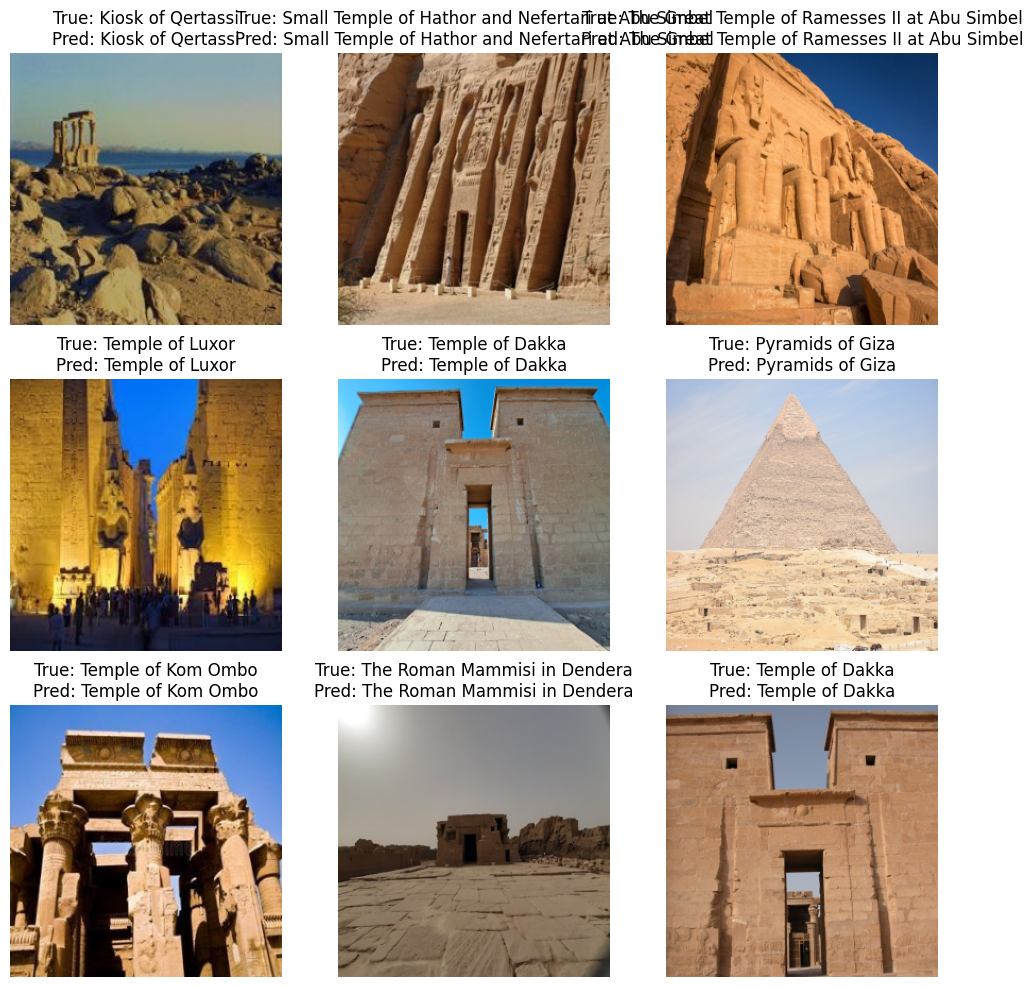

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def display_batch(dataset, encoder=None, n=9):
    batch = dataset.dataset.shuffle(buffer_size=1000).take(1)
    for images, labels in batch:
        preds = model.predict(images)
        preds_classes = np.argmax(preds, axis=1)
        break

    plt.figure(figsize=(12, 12))
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        img = images[i].numpy()

        if img.max() > 1.0: #matplot lib expects images to be [0-1] or [0-255 uint(ours is float)],images here have not gone through normalization of [0,1], thats why we normalize to display
            img = img / 255.0

        plt.imshow(np.clip(img, 0, 1))
        if encoder:
            true_label = encoder.inverse_transform([int(labels[i].numpy())])[0]
            pred_label = encoder.inverse_transform([preds_classes[i]])[0]
        else:
            true_label = int(labels[i].numpy())
            pred_label = preds_classes[i]

        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")
    plt.show()

display_batch(test_data, encoder=encoder, n=9)


In [3]:
import pickle

model = load_model(r"C:\Uni\4th Year\GP\Implementation\Recognition\Landmarks\Mobile Net V2 - AUG\Mobile Net V2.keras")

with open(r"C:\Uni\4th Year\GP\Implementation\Recognition\Landmarks\Mobile Net V2 - AUG\label_encoder (1).pkl", "rb") as f:
    encoder = pickle.load(f)

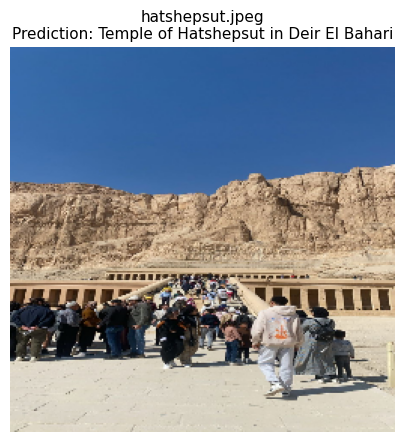

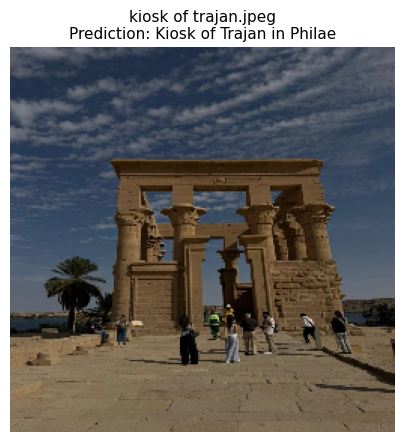

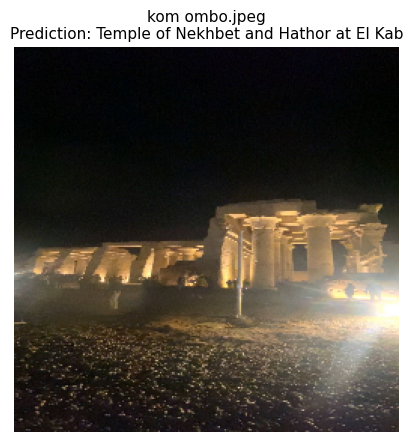

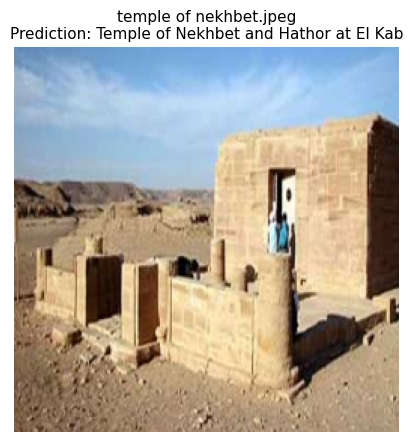

In [5]:
TEST_FOLDER = r"C:\Uni\4th Year\GP\Implementation\Recognition\Landmarks\test_samples"
IMAGE_SIZE = 256
MAX_IMAGES = 12

image_files = [f for f in os.listdir(TEST_FOLDER) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:MAX_IMAGES]

for img_file in image_files:
    img_path = os.path.join(TEST_FOLDER, img_file)

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Could not read {img_path}")
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE)) # Resize to model input size
    #no normalize form 255 to 1 since model was trained on 0-255 images(what mobilenet expects)
    x = np.expand_dims(img_resized, axis=0) 
    pred = model.predict(x, verbose=0) # already exists pre_process_input
    pred_id = np.argmax(pred, axis=1)[0]
    pred_label = encoder.inverse_transform([pred_id])[0]

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.title(f"{img_file}\nPrediction: {pred_label}", fontsize=11)
    plt.axis("off")
    plt.show()

In [ ]:
import pickle
model.save('/kaggle/working/Mobile Net V2.keras')

encoder_file = "label_encoder.pkl"

with open(encoder_file, "wb") as f:
    pickle.dump(encoder, f)